# Preprocessing

## Kaggle Configuration

In [11]:
!pwd
!whoami
!ls
!cd ../;ls;nvidia-smi;cd /;ls;!system;cat /etc/os-release;uname -a

/kaggle/working
root
state.db
input  lib  working
Mon Sep 21 13:41:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             31W /   70W |     269MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A 

In [32]:
# Testing GPU acceleration for data frames enabled for using cudf()
import cudf
import cupy as cp

df = cudf.DataFrame({
    "a": cp.arange(10_000_000)
})

df["b"] = df["a"] * 2
print(df.head())

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

   a  b
0  0  0
1  1  2
2  2  4
3  3  6
4  4  8
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged27.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged51.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged41.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged02.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged22.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged14.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged53.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged01.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged29.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged52.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged35.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged05.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged16.csv
/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV/Merged08.csv
/kaggle/input/

## CICIoT2023
> CICIoT2023 is a large-scale, real-time IoT network traffic dataset designed for benchmarking intrusion detection systems (IDS) in heterogeneous IoT environments. It captures both benign network activity and 33 distinct attack types executed by compromised IoT devices targeting other devices within a controlled testbed.
>
>It has seven major categories.
> - DDoS and DoS
> - Reconnaissance
> - Web-based attacks
> - Brute Force
> - Spoofing
> - Mirai (Botnet attack)
> - Other network-level attacks

In [9]:
data_dir = "/kaggle/input/datasets/g1xtreme/ciciot2023/MERGED_CSV"

In [10]:
import os
import cudf

csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

headers_dict = {}

for file in csv_files:
    file_path = os.path.join(data_dir, file)

    try:
        # Read only the header
        df = cudf.read_csv(file_path, nrows=0)
        headers_dict[file] = list(df.columns)

    except Exception as e:
        headers_dict[file] = f"Error reading file: {e}"

for fname, headers in headers_dict.items():
    print(f"\nFile: {fname}")
    print(headers)


File: Merged27.csv
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']

File: Merged51.csv
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']

File: Merged41.csv
['Header_Length', 'Protocol Type', 'Time_To_

### try to use merge using gpu - then 

In [3]:
import pandas as pd
import os

csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

big_df = []

for file in csv_files:
    path = os.path.join(data_dir, file)
    print(file)
    df = pd.read_csv(path)
    big_df.append(df)
merged = pd.concat(
    big_df,
    ignore_index=True
)
merged.to_parquet(
    "/kaggle/working/CICIOT2023_FULL.parquet"
)
!ls

Merged27.csv
Merged51.csv
Merged41.csv
Merged02.csv
Merged22.csv
Merged14.csv
Merged53.csv
Merged01.csv
Merged29.csv
Merged52.csv
Merged35.csv
Merged05.csv
Merged16.csv
Merged08.csv
Merged06.csv
Merged26.csv
Merged42.csv
Merged58.csv
Merged61.csv
Merged36.csv
Merged04.csv
Merged25.csv
Merged47.csv
Merged17.csv
Merged50.csv
Merged39.csv
Merged24.csv
Merged34.csv
Merged44.csv
Merged21.csv
Merged12.csv
Merged23.csv
Merged38.csv
Merged60.csv
Merged32.csv
Merged19.csv
Merged03.csv
Merged07.csv
Merged28.csv
Merged45.csv
Merged33.csv
Merged09.csv
Merged13.csv
Merged43.csv
Merged48.csv
Merged49.csv
Merged37.csv
Merged18.csv
Merged20.csv
Merged11.csv
Merged63.csv
Merged62.csv
Merged57.csv
Merged30.csv
Merged40.csv
Merged15.csv
Merged54.csv
Merged55.csv
Merged31.csv
Merged46.csv
Merged59.csv
Merged10.csv
Merged56.csv
CICIOT2023_FULL.parquet  state.db


In [16]:
from dask_cuda import LocalCUDACluster
from dask.distributed import Client
import dask_cudf

cluster = LocalCUDACluster()
client = Client(cluster)

ddf = dask_cudf.read_parquet(
    "/kaggle/working/CICIOT2023_FULL.parquet"
)

print("Rows:", ddf.shape[0].compute())
print("Cols:", len(ddf.columns))
print("Labels:", ddf["Label"].nunique().compute())
print(
    "Nulls:",
    ddf.isnull().sum().sum().compute()
)

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36589 instead
  warnings.warn(


Rows: 45019243
Cols: 40


2026-09-21 16:59:14,795 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d26cba58b103b766af94a221e8aab5d3 initialized by task ('shuffle-transfer-d26cba58b103b766af94a221e8aab5d3', 1) executed on worker tcp://127.0.0.1:44027
2026-09-21 16:59:15,118 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d26cba58b103b766af94a221e8aab5d3 deactivated due to stimulus 'task-finished-1790009955.117572'


Labels: 34
Nulls: 1498


2026-09-21 16:59:37,626 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67cc474a6dc594fd913edec41a468601 initialized by task ('shuffle-transfer-67cc474a6dc594fd913edec41a468601', 3) executed on worker tcp://127.0.0.1:44027
2026-09-21 16:59:56,267 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 10.64 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:00:07,250 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 12.39 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:00:07,255 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memor

Rows after cleaning: 21004851


2026-09-21 17:01:06,386 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67cc474a6dc594fd913edec41a468601 initialized by task ('shuffle-transfer-67cc474a6dc594fd913edec41a468601', 3) executed on worker tcp://127.0.0.1:44027
2026-09-21 17:01:33,687 - distributed.worker.memory - WARNING - Worker is at 85% memory usage. Pausing worker.  Process memory: 12.76 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:01:35,489 - distributed.worker.memory - WARNING - Worker is at 72% memory usage. Resuming worker. Process memory: 10.90 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:01:39,152 - distributed.worker.memory - WARNING - Worker is at 86% memory usage. Pausing worker.  Process memory: 13.03 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:01:44,052 - distributed.worker.memory - WARNING - Worker is at 64% memory usage. Resuming worker. Process memory: 9.69 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:01:46,566 - distributed.worker.memory - WARNING - Worker is at 8

Label
DDOS-UDP_FLOOD             1964080
DDOS-ICMP_FLOOD            1907555
DOS-UDP_FLOOD              1851290
DDOS-SYN_FLOOD             1764624
DDOS-PSHACK_FLOOD          1641901
DDOS-TCP_FLOOD             1560642
DDOS-RSTFINFLOOD           1255786
DDOS-SYNONYMOUSIP_FLOOD    1171376
DOS-SYN_FLOOD              1138628
DOS-TCP_FLOOD              1120194
BENIGN                     1047308
MIRAI-GREETH_FLOOD          897599
MIRAI-UDPPLAIN              767300
MIRAI-GREIP_FLOOD           694293
DDOS-ICMP_FRAGMENTATION     431149
VULNERABILITYSCAN           356325
DDOS-UDP_FRAGMENTATION      273394
DDOS-ACK_FRAGMENTATION      271537
MITM-ARPSPOOFING            269044
DNS_SPOOFING                167017
RECON-HOSTDISCOVERY         127869
RECON-OSSCAN                 92323
RECON-PORTSCAN               76789
DOS-HTTP_FLOOD               68444
DDOS-HTTP_FLOOD              27597
DDOS-SLOWLORIS               22399
DICTIONARYBRUTEFORCE         12520
BROWSERHIJACKING              5560
COMMANDINJECTI

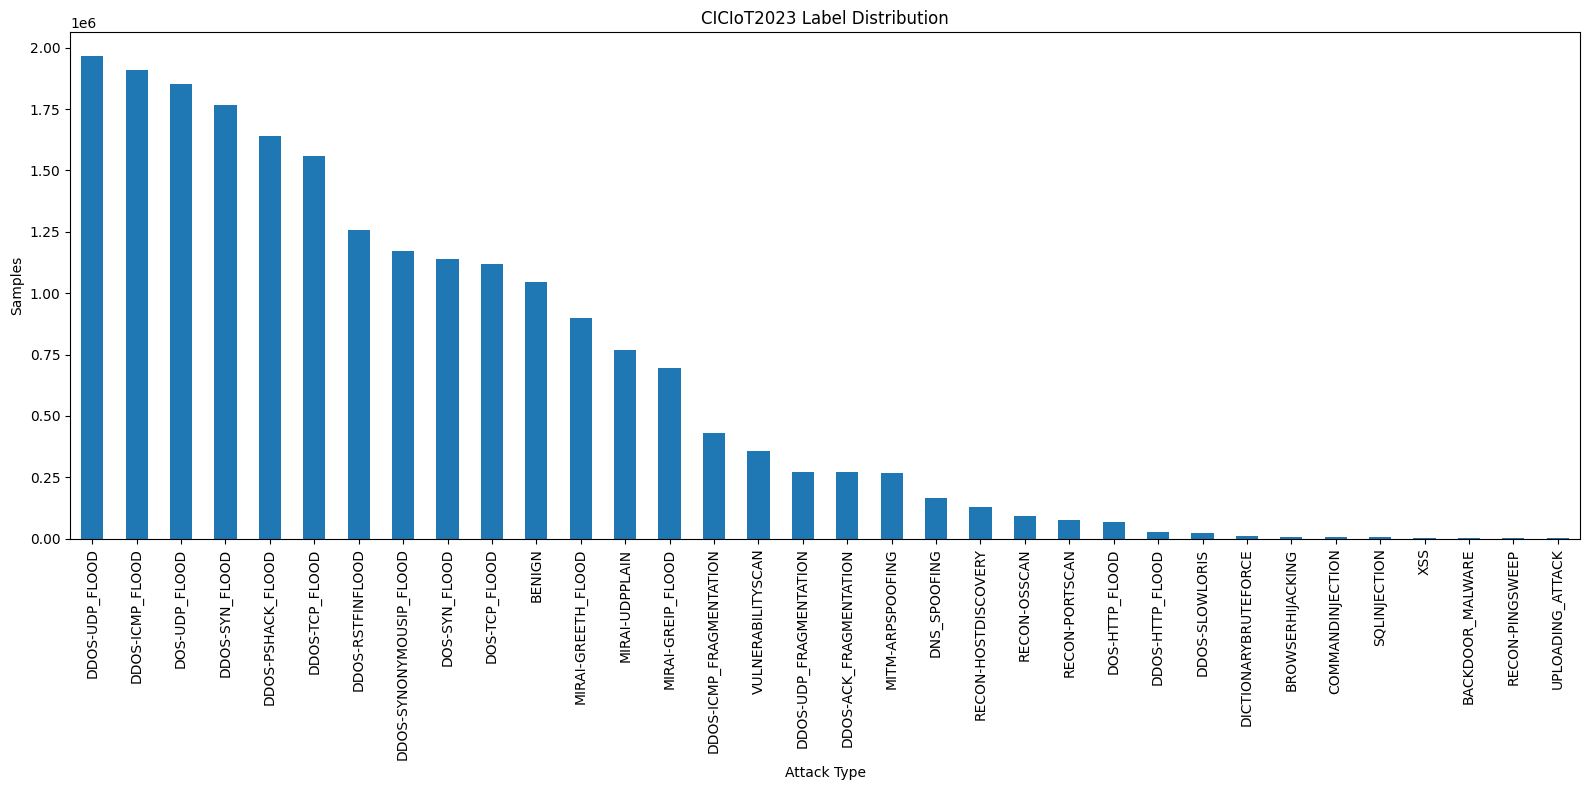

In [17]:

# Remove rows containing any null value and duplicates
ddf = ddf.dropna()
ddf = ddf.drop_duplicates()
# Verify
print("Rows after cleaning:",
ddf.shape[0].compute())

# Class distribution
label_counts = (
    ddf["Label"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

print(label_counts)

import matplotlib.pyplot as plt

# Convert to pandas for plotting
label_counts_pd = label_counts.to_pandas()

plt.figure(figsize=(16, 8))
label_counts_pd.plot(kind="bar")

plt.title("CICIoT2023 Label Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

BENIGN → Normal, non‑malicious network traffic.

UPLOADING_ATTACK → Malicious file upload attempt to compromise a server.

DICTIONARYBRUTEFORCE → Automated password guessing using dictionary wordlists.

COMMANDINJECTION → Exploiting input fields to run system commands.

SQLINJECTION → Injecting SQL queries to manipulate or steal database data.

XSS → Injecting malicious scripts into web pages for client‑side execution.

DOS-HTTP_FLOOD → Overwhelming a server with excessive HTTP requests.

DOS-UDP_FLOOD → Flooding a target with UDP packets to exhaust resources.

DOS-SYN_FLOOD → Exploiting TCP handshake by sending massive SYN requests.

DOS-TCP_FLOOD → Flooding with TCP packets to disrupt services.

DDOS-HTTP_FLOOD → Distributed HTTP request flood from multiple sources.

DDOS-UDP_FLOOD → Distributed UDP packet flood attack.

DDOS-SYN_FLOOD → Distributed SYN flood attack targeting TCP handshake.

DDOS-TCP_FLOOD → Distributed TCP packet flood attack.

DDOS-ICMP_FLOOD → Distributed ICMP echo request flood.

DDOS-RSTFINFLOOD → Flooding with TCP RST/FIN flags to disrupt connections.

DDOS-PSHACK_FLOOD → Flooding with TCP PSH/ACK packets to overload systems.

DDOS-UDP_FRAGMENTATION → Fragmented UDP packets sent in floods to exhaust reassembly.

DDOS-ACK_FRAGMENTATION → Fragmented ACK floods targeting TCP reassembly.

DDOS-ICMP_FRAGMENTATION → Fragmented ICMP floods to overload packet handling.

DDOS-SYNONYMOUSIP_FLOOD → Flood using spoofed IPs with similar ranges.

DDOS-SLOWLORIS → Holding many half‑open HTTP connections to exhaust server threads.

MIRAI-UDPPLAIN → IoT botnet sending plain UDP floods.

MIRAI-GREIP_FLOOD → IoT botnet flooding with GRE over IP packets.

MIRAI-GREETH_FLOOD → IoT botnet flooding with GRE over Ethernet packets.

MITM-ARPSPOOFING → Man‑in‑the‑middle attack by poisoning ARP tables.

DNS_SPOOFING → Redirecting DNS queries to malicious servers.

RECON-PORTSCAN → Scanning ports to identify open services.

RECON-OSSCAN → Fingerprinting operating systems via network probes.

RECON-PINGSWEEP → Sending ICMP pings to discover active hosts.

RECON-HOSTDISCOVERY → Mapping live hosts in a network.

VULNERABILITYSCAN → Automated probing for known software vulnerabilities.

BACKDOOR_MALWARE → Malicious software creating hidden remote access.

BROWSERHIJACKING → Malicious takeover of browser settings or sessions.

In [18]:

mapping = {
    # Normal
    "BENIGN": "Normal",

    # DDoS
    "DDOS-ICMP_FLOOD": "DDoS",
    "DDOS-UDP_FLOOD": "DDoS",
    "DDOS-TCP_FLOOD": "DDoS",
    "DDOS-PSHACK_FLOOD": "DDoS",
    "DDOS-SYN_FLOOD": "DDoS",
    "DDOS-RSTFINFLOOD": "DDoS",
    "DDOS-SYNONYMOUSIP_FLOOD": "DDoS",
    "DDOS-ICMP_FRAGMENTATION": "DDoS",
    "DDOS-UDP_FRAGMENTATION": "DDoS",
    "DDOS-ACK_FRAGMENTATION": "DDoS",
    "DDOS-HTTP_FLOOD": "DDoS",
    "DDOS-SLOWLORIS": "DDoS",

    # DoS
    "DOS-UDP_FLOOD": "DoS",
    "DOS-TCP_FLOOD": "DoS",
    "DOS-SYN_FLOOD": "DoS",
    "DOS-HTTP_FLOOD": "DoS",

    # Botnet
    "MIRAI-GREETH_FLOOD": "Botnet",
    "MIRAI-UDPPLAIN": "Botnet",
    "MIRAI-GREIP_FLOOD": "Botnet",
    "BACKDOOR_MALWARE": "Botnet",

    # Recon
    "RECON-HOSTDISCOVERY": "Recon",
    "RECON-OSSCAN": "Recon",
    "RECON-PORTSCAN": "Recon",
    "RECON-PINGSWEEP": "Recon",
    "VULNERABILITYSCAN": "Recon",

    # Spoofing
    "DNS_SPOOFING": "Spoofing",
    "MITM-ARPSPOOFING": "Spoofing",

    # Brute Force
    "DICTIONARYBRUTEFORCE": "BruteForce",

    # Web Attack
    "SQLINJECTION": "WebAttack",
    "XSS": "WebAttack",
    "COMMANDINJECTION": "WebAttack",
    "UPLOADING_ATTACK": "WebAttack",
    "BROWSERHIJACKING": "WebAttack",
}

# Apply mapping
ddf["Label"] = ddf["Label"].map(mapping)

# Verify
print(
    ddf["Label"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

/usr/local/lib/python3.12/dist-packages/dask/dataframe/dask_expr/_collection.py:4218: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func, meta=('Label', 'object'))

  warnings.warn(meta_warning(meta, method="map"))
2026-09-21 17:03:57,456 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67cc474a6dc594fd913edec41a468601 initialized by task ('shuffle-transfer-67cc474a6dc594fd913edec41a468601', 3) executed on worker tcp://127.0.0.1:44027
2026-09-21 17:04:29,680 - distributed.worker.memory - WARNING - Worker is at 85% memory usage. Pausing worker.  Process memory: 12.85 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:04:30,971 - distributed.worker.memory - WARNING - Wor

Label
DDoS          12292040
DoS            4178556
Botnet         2362267
Normal         1047308
Recon           655467
Spoofing        436061
WebAttack        20632
BruteForce       12520
Name: count, dtype: int64


## Saving the preprocessed Dataset

In [19]:
output_path = "/kaggle/working/CICIOT2023_CLEANED_8CLASS"

ddf.to_parquet(
    output_path,
    write_index=False
)

print("Saved to:", output_path)

2026-09-21 17:07:03,790 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67cc474a6dc594fd913edec41a468601 initialized by task ('shuffle-transfer-67cc474a6dc594fd913edec41a468601', 3) executed on worker tcp://127.0.0.1:44027
2026-09-21 17:07:33,767 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 11.25 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:07:56,067 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 12.07 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:07:56,892 - distributed.worker.memory - WARNING - Worker is at 74% memory usage. Resuming worker. Process memory: 11.21 GiB -- Worker memory limit: 15.00 GiB
2026-09-21 17:08:23,759 - distributed.shuffle._scheduler_plugin - 

Saved to: /kaggle/working/CICIOT2023_CLEANED_8CLASS


/tmp/ipykernel_58/1619406122.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


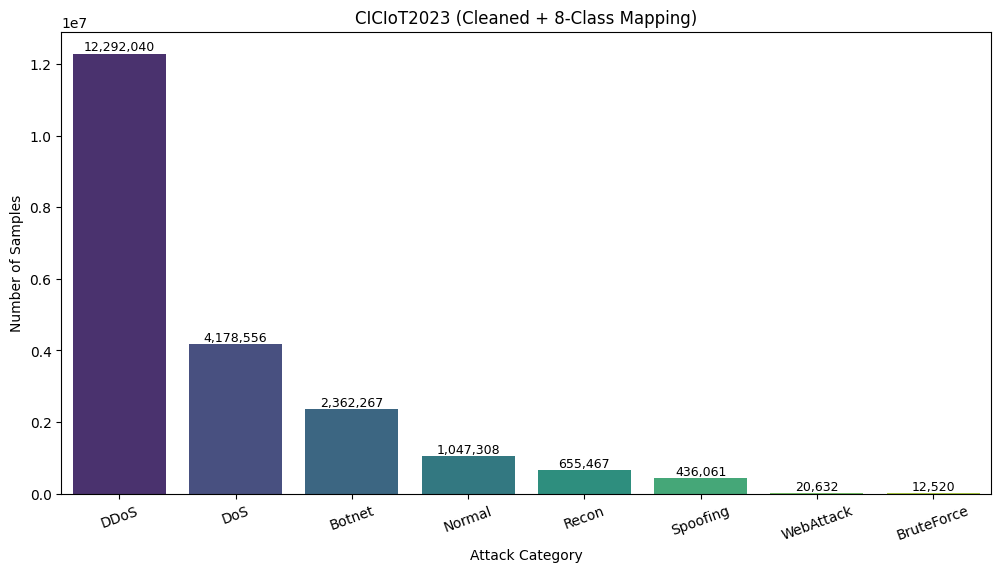

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

counts = {
    "DDoS": 12292040,
    "DoS": 4178556,
    "Botnet": 2362267,
    "Normal": 1047308,
    "Recon": 655467,
    "Spoofing": 436061,
    "WebAttack": 20632,
    "BruteForce": 12520,
}

label_counts = pd.Series(counts).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette="viridis"
)

plt.title("CICIoT2023 (Cleaned + 8-Class Mapping)")
plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)

for i, v in enumerate(label_counts.values):
    plt.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

In [5]:
columns = ('Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate','fin_flag_number', 'syn_flag_number', 'rst_flag_number','psh_flag_number', 'ack_flag_number', 'ece_flag_number','cwr_flag_number', 'ack_count', 'syn_count', 'fin_count','rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH','IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC','Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT','Number', 'Variance', 'Label')
print(len(columns))

40


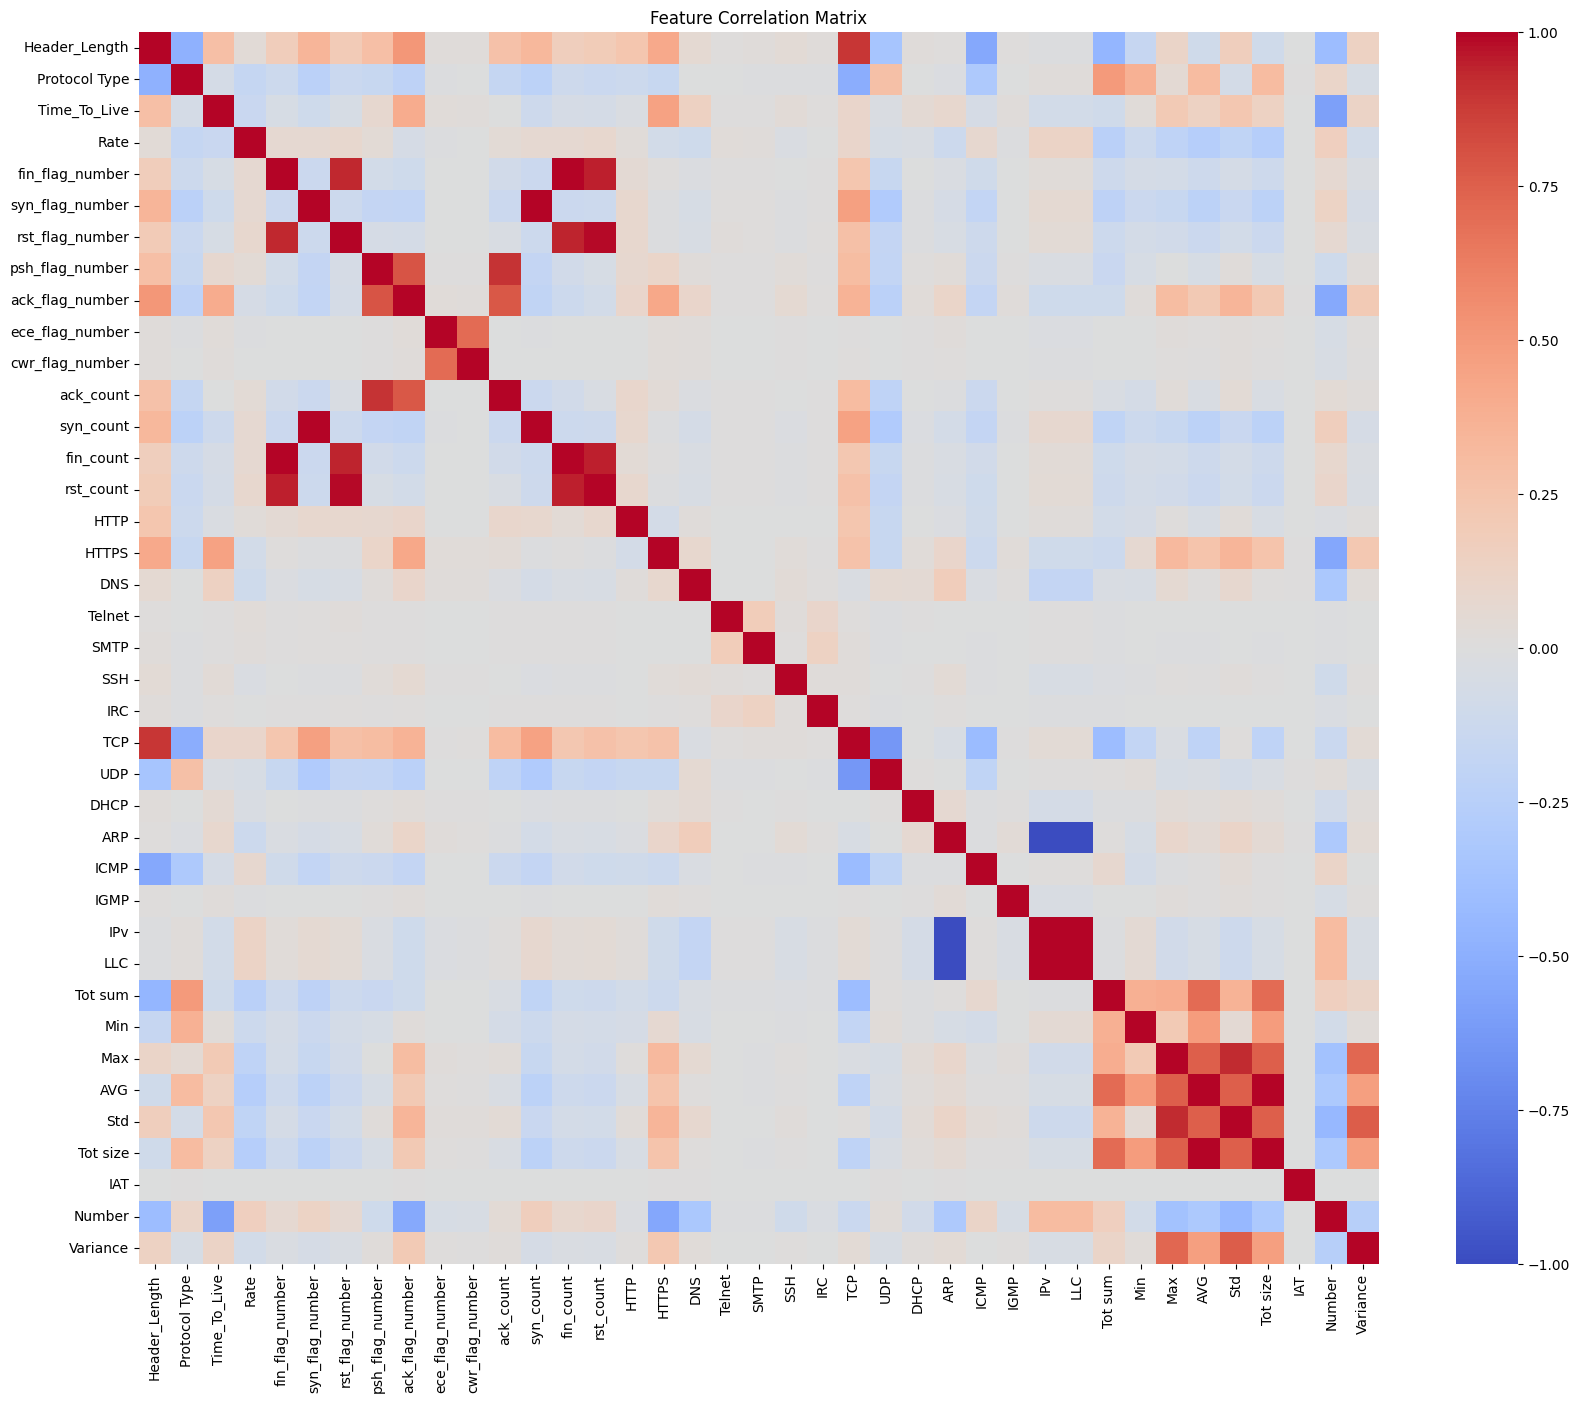

In [4]:
import dask_cudf

ddf = dask_cudf.read_parquet(
    "/kaggle/working/CICIOT2023_CLEANED_8CLASS"
)

# 1-2% sample is enough
sample_df = (
    ddf.sample(frac=0.01, random_state=42)
       .compute()
)

import matplotlib.pyplot as plt
import seaborn as sns

# Remove label
X = sample_df.drop(columns=["Label"])

corr = X.corr().to_pandas()
plt.figure(figsize=(20,16))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()


In [5]:
corr_abs = corr.abs()

high_corr = []

for i in range(len(corr_abs.columns)):
    for j in range(i):
        if corr_abs.iloc[i, j] > 0.90:
            high_corr.append(
                (
                    corr_abs.columns[i],
                    corr_abs.columns[j],
                    corr_abs.iloc[i, j]
                )
            )

for f1, f2, val in sorted(
    high_corr,
    key=lambda x: x[2],
    reverse=True
):
    print(
        f"{f1:20s} <-> {f2:20s} : {val:.4f}"
    )

IPv                  <-> ARP                  : 1.0000
LLC                  <-> ARP                  : 1.0000
LLC                  <-> IPv                  : 1.0000
Tot size             <-> AVG                  : 1.0000
fin_count            <-> fin_flag_number      : 0.9977
syn_count            <-> syn_flag_number      : 0.9927
rst_count            <-> rst_flag_number      : 0.9887
rst_count            <-> fin_count            : 0.9525
rst_count            <-> fin_flag_number      : 0.9494
fin_count            <-> rst_flag_number      : 0.9397
rst_flag_number      <-> fin_flag_number      : 0.9372
Std                  <-> Max                  : 0.9249
ack_count            <-> psh_flag_number      : 0.9059


In [15]:
len(ddf.columns) - 1

32

In [18]:
# Encode labels

df["Label"] = df["Label"].astype("category")

label_mapping = dict(
    enumerate(
        df["Label"].cat.categories.to_pandas()
    )
)

df["Label"] = df["Label"].cat.codes

print(label_mapping)
print(df["Label"].nunique())

reverse_mapping = {
    v: k for k, v in label_mapping.items()
}

{0: 'Botnet', 1: 'BruteForce', 2: 'DDoS', 3: 'DoS', 4: 'Normal', 5: 'Recon', 6: 'Spoofing', 7: 'WebAttack'}
8


# work from here

## Centralised Model Dataset

### Dataset for XgBoost

In [10]:
import pandas as pd

needed_cols = [
    "Header_Length", "Time_To_Live", "Rate", "fin_flag_number",
    "syn_flag_number", "rst_flag_number", "psh_flag_number",
    "ack_flag_number", "ece_flag_number", "cwr_flag_number",
    "ack_count", "syn_count", "fin_count", "rst_count",
    "HTTP", "HTTPS", "DNS", "Telnet", "SMTP", "SSH", "IRC",
    "TCP", "UDP", "DHCP", "ARP", "ICMP", "IGMP", "IPv", "LLC",
    "Tot size", "IAT", "Number", "Label"
]

df = pd.read_parquet(file_path, columns=needed_cols, engine="pyarrow")
df.to_parquet(r"C:\Users\jeeva\Documents\FedSentry\data\processed\xgboost_dataset.parquet", engine="pyarrow", index=False)


### Dataset for FNN

## Federated Learning Dataset

### Creating IID Dataset
Balanced distribution of all attack categories across clients.

### Mild Non-IID Dataset
Slight skew in the distribution of all attacks categories across clients.

### Moderate Non-IID Dataset
Stronger skew in the distribution of all attacks categories across clients.

### Extreme Heterogeneity Dataset
Extreme heterogeneity - Clients will only see one type of attack.